# ACADIA 2023 Workshop - Day 1 Tutorial

## Introduction to topologic_fast

This notebook is an adaptation of the ACADIA 2023 Day 1 topologicpy tutorial for the `topologic_fast` library.

`topologic_fast` is a high-performance Rust implementation of non-manifold topology operations for architectural and engineering applications.

### Topics Covered:
- Creating basic topological elements (Vertex, Edge, Wire, Face, Cell, CellComplex)
- Querying topological properties
- Visualizing with Plotly
- Graph operations

In [1]:
# Import topologic_fast
import topologic_fast as tf
import plotly.graph_objects as go
import math

print("Done importing libraries")

Done importing libraries


## 1. Creating a Vertex

A Vertex is the simplest topological element - a point in 3D space.

In [2]:
# Create a vertex at coordinates (10, 0, 0)
v1 = tf.Vertex.ByCoordinates(10, 0, 0)
print(v1)

Vertex(10.0000, 0.0000, 0.0000)


In [3]:
# Get the coordinates of the vertex
print(v1.Coordinates())

(10.0, 0.0, 0.0)


In [4]:
# Get the X coordinate
print(v1.X())

10.0


## 2. Creating an Edge

An Edge connects two vertices.

In [5]:
# Create a second vertex
v2 = tf.Vertex.ByCoordinates(10, 10, 0)

# Create an edge from v1 to v2
e1 = tf.Edge.ByStartVertexEndVertex(v1, v2)
print(e1)

Edge(length=10.0000)


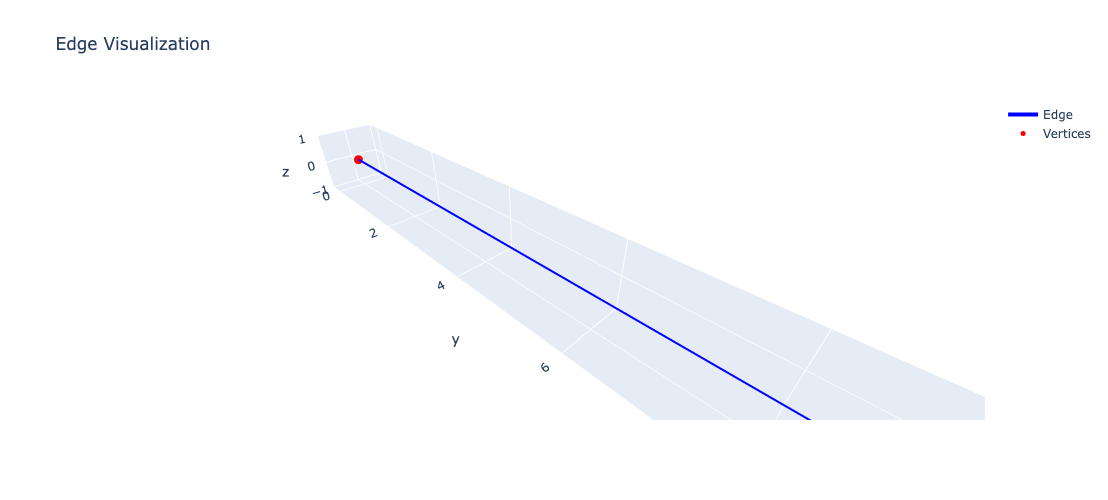

In [6]:
def show_edge(edge, vertex_size=5):
    """Visualize an edge using Plotly"""
    fig = go.Figure()
    
    # Get edge vertices
    start, end = edge.Vertices()
    p1 = start.Coordinates()
    p2 = end.Coordinates()
    
    # Draw edge
    fig.add_trace(go.Scatter3d(
        x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
        mode='lines',
        line=dict(color='blue', width=4),
        name='Edge'
    ))
    
    # Draw vertices
    fig.add_trace(go.Scatter3d(
        x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
        mode='markers',
        marker=dict(size=vertex_size, color='red'),
        name='Vertices'
    ))
    
    fig.update_layout(
        title='Edge Visualization',
        scene=dict(aspectmode='data'),
        width=700, height=500
    )
    
    return fig

show_edge(e1, vertex_size=5).show()

## 3. Creating a Cell (3D Volume)

A Cell is a 3D volume bounded by Faces. We can create a box (prism) Cell.

In [7]:
# Create a box cell
# Note: topologic_fast uses Cell.Box with origin and dimensions
# The topologicpy Cell.Prism(width, length, height, uSides, vSides, wSides) is not directly available
# We create a simple box instead

c = tf.Cell.Box(0, 0, 0, 5, 3, 2)  # origin_x, origin_y, origin_z, width, length, height

print(f"Cell created with volume: {c.Volume():.3f}")

Cell created with volume: 30.000


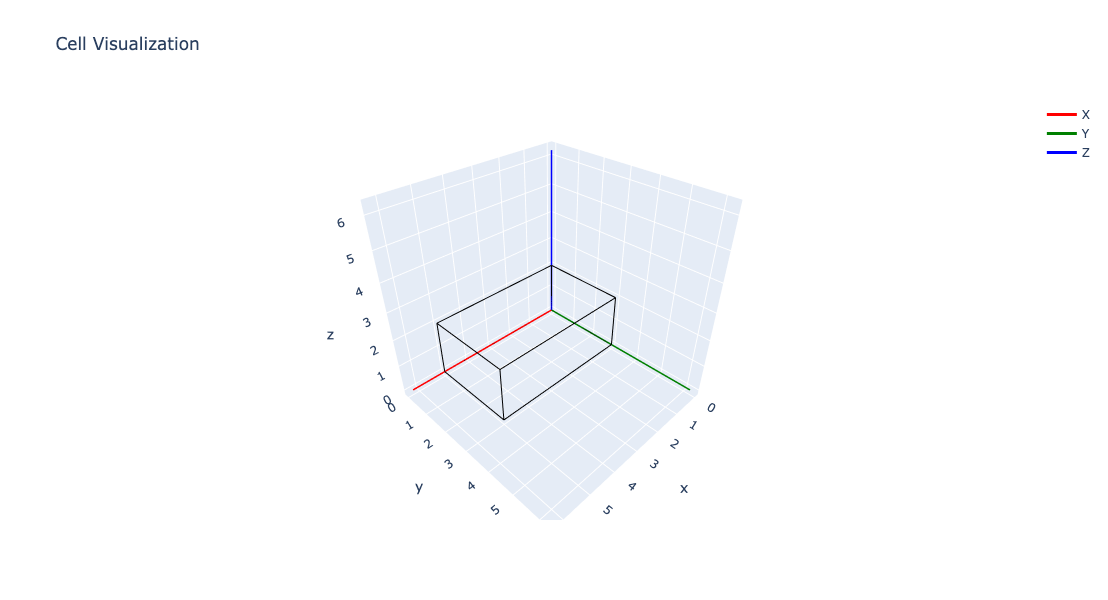

In [8]:
def show_cell(cell, face_color='lightblue', opacity=0.7):
    """Visualize a cell using Plotly"""
    fig = go.Figure()
    
    faces = cell.Faces()
    
    for i, face in enumerate(faces):
        vertices = face.Vertices()
        coords = [v.Coordinates() for v in vertices]
        
        if len(coords) >= 3:
            x = [c[0] for c in coords]
            y = [c[1] for c in coords]
            z = [c[2] for c in coords]
            
            fig.add_trace(go.Mesh3d(
                x=x, y=y, z=z,
                color=face_color,
                opacity=opacity,
                alphahull=0,
                showlegend=False
            ))
            
            # Add edges
            for k in range(len(coords)):
                p1 = coords[k]
                p2 = coords[(k + 1) % len(coords)]
                fig.add_trace(go.Scatter3d(
                    x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                    mode='lines',
                    line=dict(color='black', width=2),
                    showlegend=False
                ))
    
    # Add axes
    max_dim = max(cell.Volume() ** (1/3) * 2, 5)
    fig.add_trace(go.Scatter3d(x=[0, max_dim], y=[0, 0], z=[0, 0], mode='lines', line=dict(color='red', width=3), name='X'))
    fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, max_dim], z=[0, 0], mode='lines', line=dict(color='green', width=3), name='Y'))
    fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[0, max_dim], mode='lines', line=dict(color='blue', width=3), name='Z'))
    
    fig.update_layout(
        title='Cell Visualization',
        scene=dict(aspectmode='data'),
        width=800, height=600
    )
    
    return fig

show_cell(c).show()

## 4. Creating a CellComplex

A CellComplex is a collection of cells that share faces.

In [9]:
# Create a CellComplex by creating multiple cells
# Note: CellComplex.Prism is not directly available, we create a grid of boxes

cells = []
for i in range(2):
    for j in range(2):
        for k in range(2):
            cell = tf.Cell.Box(i * 0.5, j * 0.5, k * 0.5, 0.5, 0.5, 0.5)
            cells.append(cell)

cc = tf.CellComplex.ByCells(cells)
print(cc)

CellComplex(cells=8, volume=1.0000)


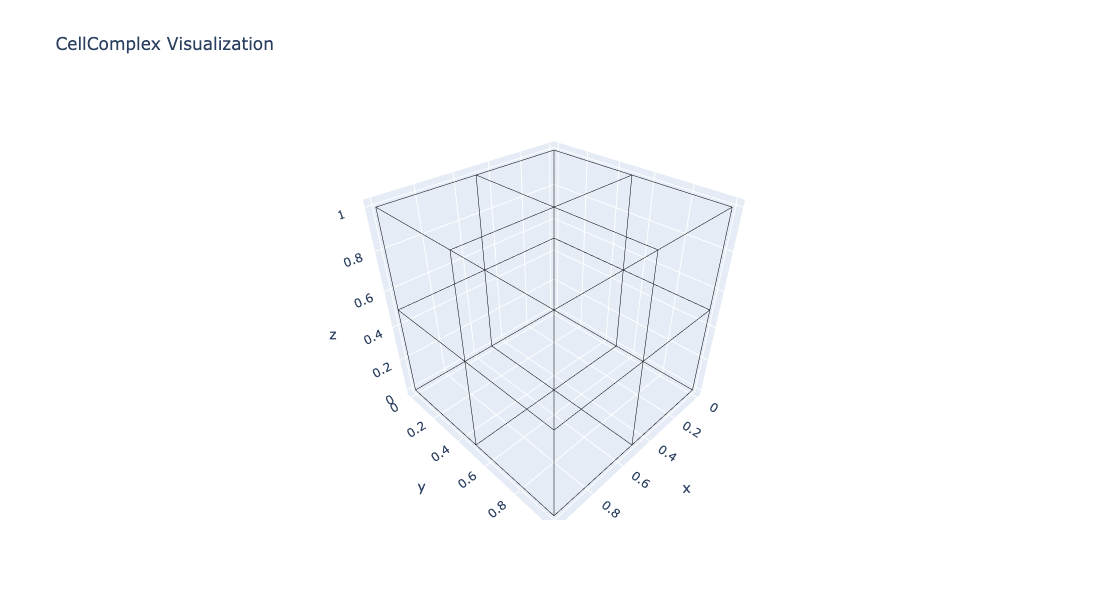

In [10]:
def show_cellcomplex(cellcomplex, face_color='lightgreen', opacity=0.5):
    """Visualize a cell complex using Plotly"""
    fig = go.Figure()
    
    faces = cellcomplex.Faces()
    
    for face in faces:
        vertices = face.Vertices()
        coords = [v.Coordinates() for v in vertices]
        
        if len(coords) >= 3:
            x = [c[0] for c in coords]
            y = [c[1] for c in coords]
            z = [c[2] for c in coords]
            
            fig.add_trace(go.Mesh3d(
                x=x, y=y, z=z,
                color=face_color,
                opacity=opacity,
                alphahull=0,
                showlegend=False
            ))
            
            # Add edges
            for k in range(len(coords)):
                p1 = coords[k]
                p2 = coords[(k + 1) % len(coords)]
                fig.add_trace(go.Scatter3d(
                    x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                    mode='lines',
                    line=dict(color='black', width=1),
                    showlegend=False
                ))
    
    fig.update_layout(
        title='CellComplex Visualization',
        scene=dict(aspectmode='data'),
        width=800, height=600
    )
    
    return fig

show_cellcomplex(cc).show()

## 5. Exploding a CellComplex

Note: The Topology.Explode method is not currently available in topologic_fast.
We demonstrate a manual explode visualization instead.

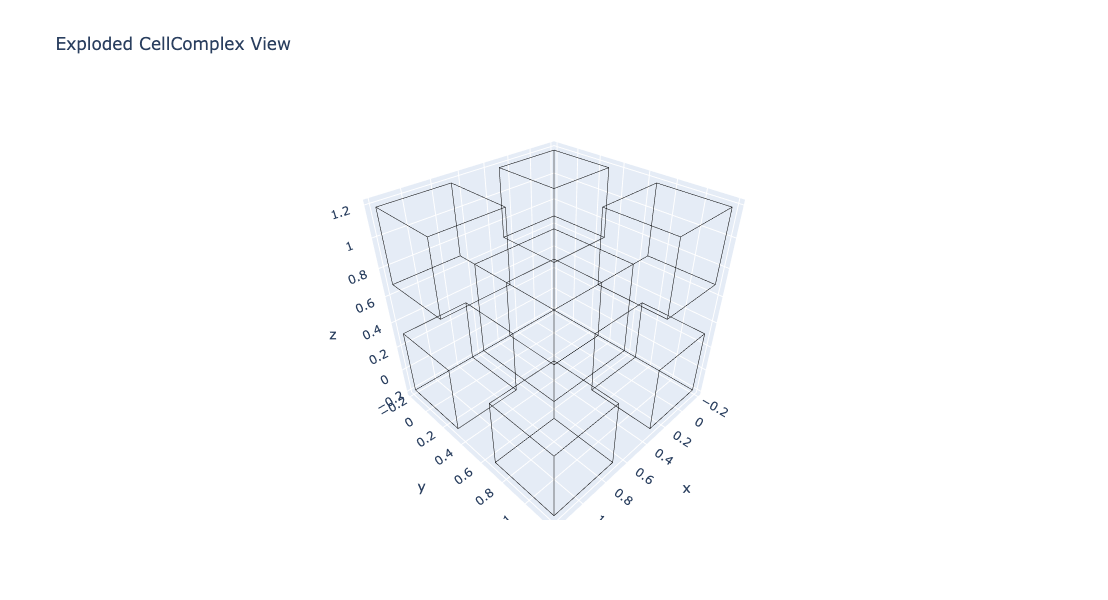

In [12]:
# NOTE: Topology.Explode is not available in topologic_fast
# We can manually offset faces for an exploded view

def explode_cellcomplex(cellcomplex, scale=1.5):
    """Create an exploded view of a cell complex"""
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    
    # Find center of complex
    total_volume = cellcomplex.Volume()
    center_x = center_y = center_z = 0
    for cell in cells:
        com = cell.CenterOfMass()
        center_x += com[0]
        center_y += com[1]
        center_z += com[2]
    center_x /= len(cells)
    center_y /= len(cells)
    center_z /= len(cells)
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F']
    
    for i, cell in enumerate(cells):
        com = cell.CenterOfMass()
        
        # Calculate offset direction
        dx = (com[0] - center_x) * (scale - 1)
        dy = (com[1] - center_y) * (scale - 1)
        dz = (com[2] - center_z) * (scale - 1)
        
        faces = cell.Faces()
        color = colors[i % len(colors)]
        
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            
            if len(coords) >= 3:
                x = [c[0] + dx for c in coords]
                y = [c[1] + dy for c in coords]
                z = [c[2] + dz for c in coords]
                
                fig.add_trace(go.Mesh3d(
                    x=x, y=y, z=z,
                    color=color,
                    opacity=0.7,
                    alphahull=0,
                    showlegend=False
                ))
                
                # Add edges
                for k in range(len(coords)):
                    p1x, p1y, p1z = coords[k][0] + dx, coords[k][1] + dy, coords[k][2] + dz
                    p2x, p2y, p2z = coords[(k+1)%len(coords)][0] + dx, coords[(k+1)%len(coords)][1] + dy, coords[(k+1)%len(coords)][2] + dz
                    fig.add_trace(go.Scatter3d(
                        x=[p1x, p2x], y=[p1y, p2y], z=[p1z, p2z],
                        mode='lines',
                        line=dict(color='black', width=1),
                        showlegend=False
                    ))
    
    fig.update_layout(
        title='Exploded CellComplex View',
        scene=dict(aspectmode='data'),
        width=800, height=600
    )
    
    return fig

explode_cellcomplex(cc, scale=1.75).show()

## 6. Finding Adjacent Cells

Note: The Topology.AdjacentTopologies method is not directly available in topologic_fast.
We can use Graph operations to find adjacencies.

In [13]:
# Get the cells from the cell complex
cells = cc.Cells()
c1 = cells[0]

# NOTE: Topology.AdjacentTopologies is not available in topologic_fast
# We can use Graph.ByTopology to find adjacencies

# Create a dual graph - vertices represent cells, edges represent shared faces
g = tf.Graph.ByTopology(cc)

print(f"Number of cells: {len(cells)}")
print(f"Graph has {g.Order()} vertices and {g.Size()} edges")

Number of cells: 8
Graph has 8 vertices and 12 edges


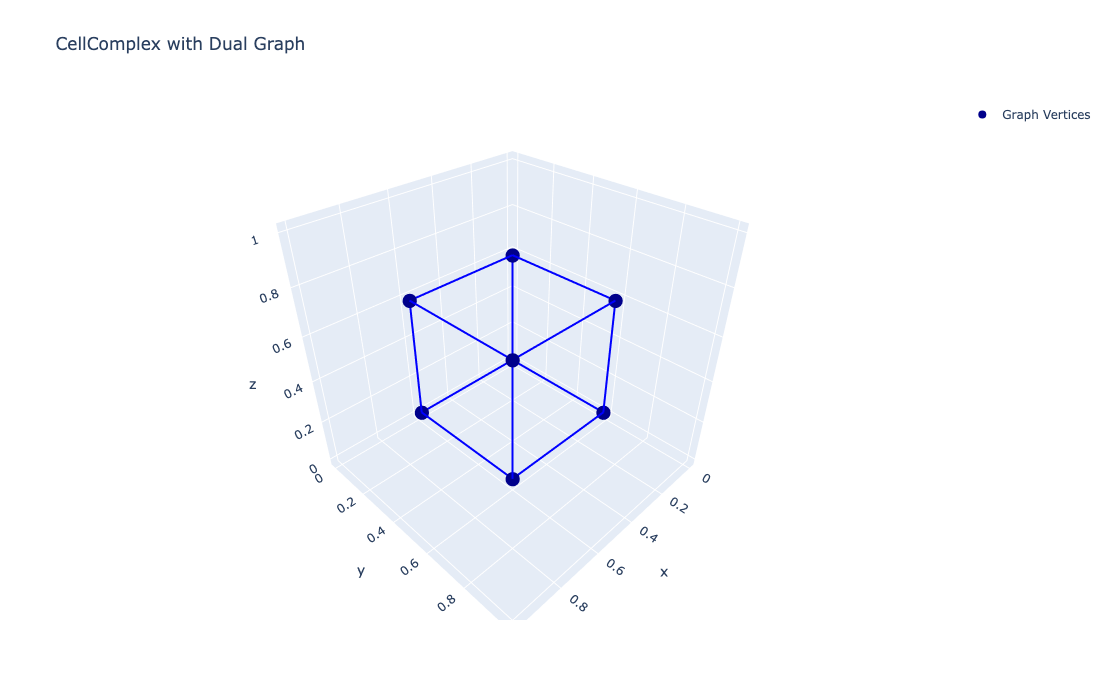

In [14]:
def show_cell_and_graph(cellcomplex, graph, highlight_cell_idx=0):
    """Visualize cell complex with its dual graph"""
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    colors = ['yellow' if i == highlight_cell_idx else 'red' for i in range(len(cells))]
    
    # Draw cells
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        opacity = 1.0 if i == highlight_cell_idx else 0.3
        
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            
            if len(coords) >= 3:
                x = [c[0] for c in coords]
                y = [c[1] for c in coords]
                z = [c[2] for c in coords]
                
                fig.add_trace(go.Mesh3d(
                    x=x, y=y, z=z,
                    color=colors[i],
                    opacity=opacity,
                    alphahull=0,
                    showlegend=False
                ))
    
    # Draw graph edges
    graph_edges = graph.Edges()
    for edge in graph_edges:
        edge_verts = edge.Vertices()
        if len(edge_verts) == 2:
            p1 = edge_verts[0].Coordinates()
            p2 = edge_verts[1].Coordinates()
            fig.add_trace(go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode='lines',
                line=dict(color='blue', width=4),
                showlegend=False
            ))
    
    # Draw graph vertices
    graph_vertices = graph.Vertices()
    vertex_coords = [v.Coordinates() for v in graph_vertices]
    x = [c[0] for c in vertex_coords]
    y = [c[1] for c in vertex_coords]
    z = [c[2] for c in vertex_coords]
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=8, color='darkblue'),
        name='Graph Vertices'
    ))
    
    fig.update_layout(
        title='CellComplex with Dual Graph',
        scene=dict(aspectmode='data'),
        width=900, height=700
    )
    
    return fig

show_cell_and_graph(cc, g).show()

## 7. Querying Cell Volume

In [15]:
# Get volume of the first cell
print(f"Volume of first cell: {c1.Volume():.6f}")

Volume of first cell: 0.125000


## 8. Creating a Building-Like Structure

Let's create a more complex example - a simple building with multiple floors.

In [16]:
# Create a simple building with multiple floors

building_cells = []
floor_height = 3.0
num_floors = 4
room_width = 5.0
room_length = 5.0
rooms_x = 3
rooms_y = 2

room_names = []

for floor in range(num_floors):
    for rx in range(rooms_x):
        for ry in range(rooms_y):
            cell = tf.Cell.Box(
                rx * room_width,
                ry * room_length,
                floor * floor_height,
                room_width,
                room_length,
                floor_height
            )
            building_cells.append(cell)
            room_names.append(f"F{floor+1}-R{rx+1}{ry+1}")

building = tf.CellComplex.ByCells(building_cells)

print(f"Building created with {building.NumCells()} rooms")
print(f"Total volume: {building.Volume():.1f} m^3")
print(f"Total surface area: {building.Area():.1f} m^2")

Building created with 24 rooms
Total volume: 1800.0 m^3
Total surface area: 2640.0 m^2


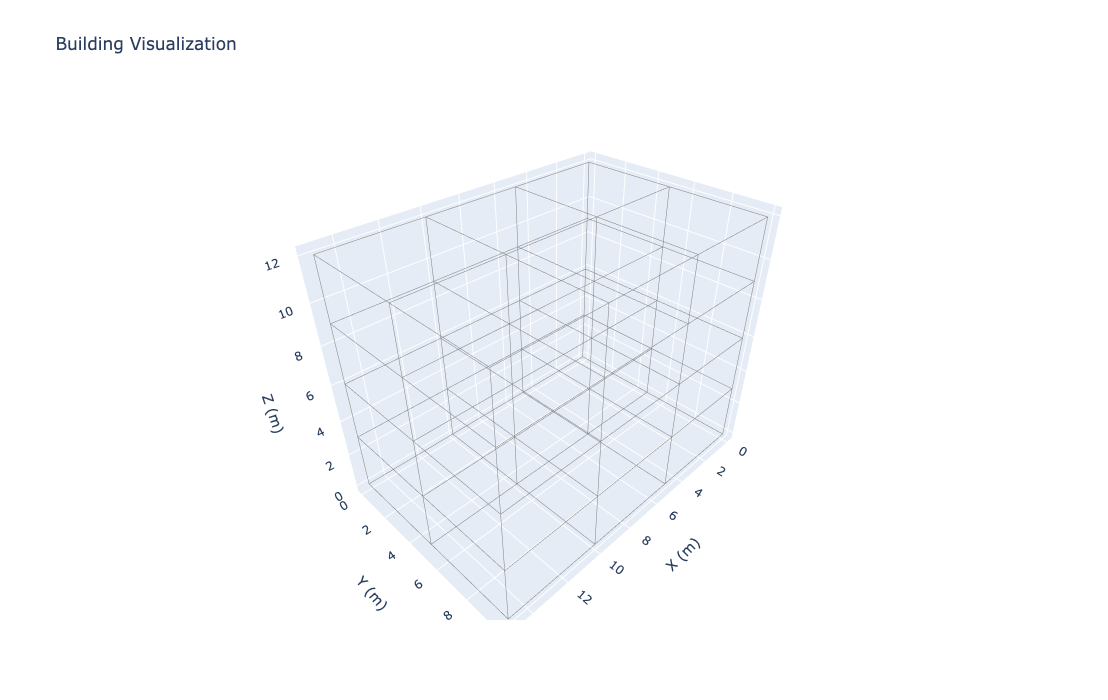

In [17]:
def show_building(cellcomplex):
    """Visualize a building-like cell complex"""
    fig = go.Figure()
    
    cells = cellcomplex.Cells()
    colors = ['#FFB6C1', '#98FB98', '#87CEEB', '#DDA0DD', '#F0E68C', '#ADD8E6']
    
    for i, cell in enumerate(cells):
        faces = cell.Faces()
        color = colors[i % len(colors)]
        
        for face in faces:
            vertices = face.Vertices()
            coords = [v.Coordinates() for v in vertices]
            
            if len(coords) >= 3:
                x = [c[0] for c in coords]
                y = [c[1] for c in coords]
                z = [c[2] for c in coords]
                
                fig.add_trace(go.Mesh3d(
                    x=x, y=y, z=z,
                    color=color,
                    opacity=0.5,
                    alphahull=0,
                    showlegend=False
                ))
                
                # Add edges
                for k in range(len(coords)):
                    p1 = coords[k]
                    p2 = coords[(k + 1) % len(coords)]
                    fig.add_trace(go.Scatter3d(
                        x=[p1[0], p2[0]], y=[p1[1], p2[1]], z=[p1[2], p2[2]],
                        mode='lines',
                        line=dict(color='gray', width=1),
                        showlegend=False
                    ))
    
    fig.update_layout(
        title='Building Visualization',
        scene=dict(
            aspectmode='data',
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900, height=700
    )
    
    return fig

show_building(building).show()

## 9. Creating and Visualizing a Graph from the Building

We create a dual graph where each room is a vertex and rooms that share a face are connected.

In [18]:
# Create a graph from the building
building_graph = tf.Graph.ByTopology(building)

print(f"Building graph:")
print(f"  Vertices (rooms): {building_graph.Order()}")
print(f"  Edges (connections): {building_graph.Size()}")
print(f"  Density: {building_graph.Density():.3f}")
print(f"  Diameter: {building_graph.Diameter()} steps")

Building graph:
  Vertices (rooms): 24
  Edges (connections): 46
  Density: 0.167
  Diameter: 6 steps


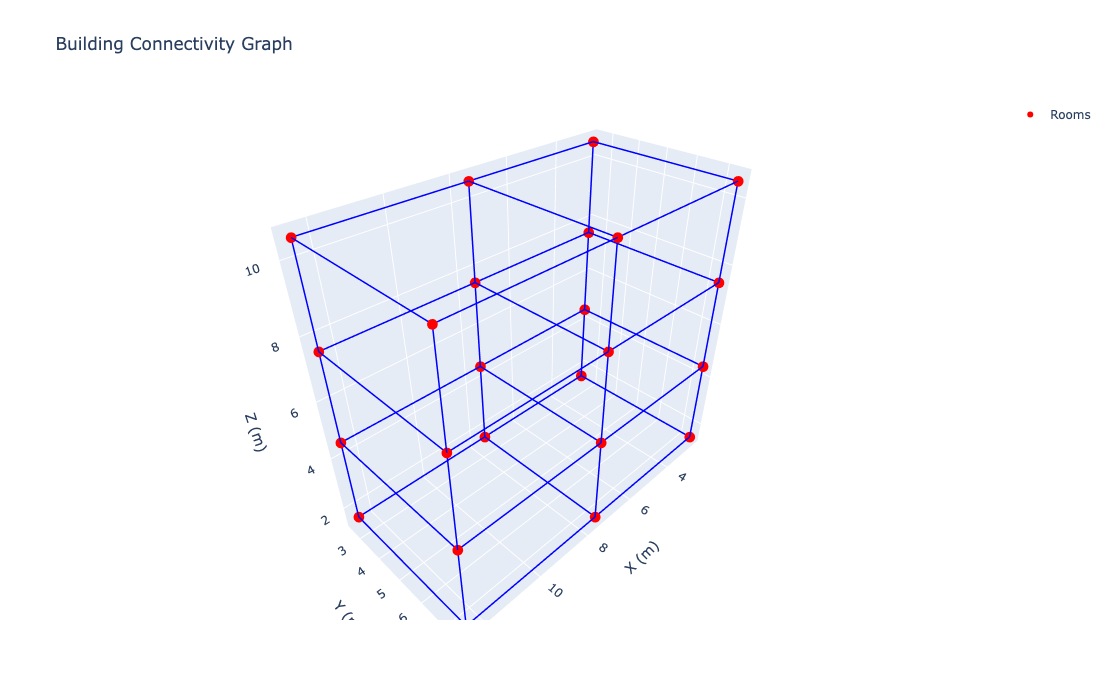

In [19]:
def show_graph_only(graph):
    """Visualize just the graph"""
    fig = go.Figure()
    
    # Draw graph edges
    graph_edges = graph.Edges()
    for edge in graph_edges:
        edge_verts = edge.Vertices()
        if len(edge_verts) == 2:
            p1 = edge_verts[0].Coordinates()
            p2 = edge_verts[1].Coordinates()
            fig.add_trace(go.Scatter3d(
                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],
                mode='lines',
                line=dict(color='blue', width=3),
                showlegend=False
            ))
    
    # Draw graph vertices
    graph_vertices = graph.Vertices()
    vertex_coords = [v.Coordinates() for v in graph_vertices]
    x = [c[0] for c in vertex_coords]
    y = [c[1] for c in vertex_coords]
    z = [c[2] for c in vertex_coords]
    
    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(size=6, color='red'),
        name='Rooms'
    ))
    
    fig.update_layout(
        title='Building Connectivity Graph',
        scene=dict(
            aspectmode='data',
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900, height=700
    )
    
    return fig

show_graph_only(building_graph).show()

## Summary

In this tutorial, we learned:

1. **Vertices** - Created points in 3D space using `tf.Vertex.ByCoordinates(x, y, z)`
2. **Edges** - Connected vertices using `tf.Edge.ByStartVertexEndVertex(v1, v2)`
3. **Cells** - Created 3D volumes using `tf.Cell.Box()`
4. **CellComplexes** - Combined cells using `tf.CellComplex.ByCells(cells)`
5. **Graphs** - Created dual graphs using `tf.Graph.ByTopology(topology)`
6. **Visualization** - Used Plotly for 3D visualization

### API Differences from topologicpy

| topologicpy | topologic_fast |
|-------------|----------------|
| `Vertex.ByCoordinates(x,y,z)` | `tf.Vertex.ByCoordinates(x,y,z)` |
| `Edge.ByVertices([v1,v2])` | `tf.Edge.ByStartVertexEndVertex(v1,v2)` |
| `Cell.Prism(width,length,height,...)` | `tf.Cell.Box(x,y,z,w,l,h)` |
| `CellComplex.Prism(...)` | `tf.CellComplex.ByCells(cells)` |
| `Topology.Show(...)` | Use Plotly directly |
| `Topology.Explode(...)` | Not directly available |
| `Topology.AdjacentTopologies(...)` | Use `tf.Graph.ByTopology()` |

### Features Not Yet Available in topologic_fast

- `Topology.Explode()` - Manual implementation needed
- `Topology.AdjacentTopologies()` - Use Graph methods instead
- `Dictionary` and dictionary transfer operations
- `DGL` (Deep Graph Library) integration